# X/Y 补偿磁场校准

扫描 X/Y 补偿电压找到 R 信号最大处，消除横磁场，展宽线宽、提高灵敏度。

## 原理
横磁场（X/Y 方向）会引入额外弛豫通道 → 展宽线宽 → 降低灵敏度。
通过扫描补偿电压找到 R 最大点 → 横磁场被最小化。

## 硬件连接说明
- **Pump 调制**: DG4000 (DG4E222800868) CH1 输出 100MHz 正弦波 → RF 开关 IN
- **RF 开关门控**: DG4000 (DG4E222800868) CH2 输出脉冲方波 → RF 开关 CTRL
- **RF 开关输出**: RF 开关 OUT → AOM（Pump 光调制）
- **X/Y 补偿**: DG4000 (DG4E234902522) CH1/X、CH2/Y

## 注意事项
- RF 开关输出端需串 0.1μF 隔直电容再接 AOM
- X/Y 补偿线圈输出 ON 时即使设为 0V 也会耦合环境噪声，务必找到最优值后保持 ON

In [39]:
from pathlib import Path
import sys
# 自动定位项目根目录
project_root = Path.cwd()
while not (project_root / "params").exists() and project_root.parent != project_root:
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import yaml
import time
import json
from datetime import datetime
import matplotlib.pyplot as plt

# 设备库
from gs200 import GS200Instrument
from signal_generator import DG4000Instrument
from tec_controller import TECInstrument
from lockin_amplifier import (
    HF2Instrument, DAQConfig, DAQResult,
    SignalInputConfig, OscillatorConfig, DemodulatorConfig,
    demod, daq,
)

print("所有库导入成功")

所有库导入成功


In [40]:
# 加载物理量→仪器映射
with open(project_root / "params" / "mapping.yaml", encoding="utf-8") as f:
    MAPPING = yaml.safe_load(f)["mapping"]

# 加载安全限值
with open(project_root / "params" / "safety_limits.yaml", encoding="utf-8") as f:
    LIMITS = yaml.safe_load(f)["safety_limits"]

# ========== 实验参数 ==========
EXPERIMENT_TYPE = "XY_Compensation_Calibration"
PURPOSE = "find_optimal_xy"

# ---- 扫描参数 ----
X_SCAN_RANGE = 0.3    # ±X 扫描范围 (V) — 小范围
Y_SCAN_RANGE = 0.3     # ±Y 扫描范围 (V) — 大范围
XY_SCAN_POINTS = 31    # 每方向扫描点数
XY_SETTLE_TIME = 0.1  # 每点等待稳定时间 (s)

# ---- 固定参数 ----
FIXED_PARAMS = {
    "Pump_laser_power": 0.1,         "Probe_laser_power": 0.1,
    "temperature": 100,              "Temp_Switch": 5.0,
    "Time_sequence": 10.0,           "main_magnetic_field": 9.3,
    "X_magnetic_field": 0.0,         "Y_magnetic_field": 0.0,
    "Time_sequence_2": 0.0,
}

# ---- Pump 调制参数 ----
PUMP_MOD_FREQ = 90e3
PUMP_MOD_AMPLITUDE = 0.18
PUMP_MOD_DUTY = 5
RF_GATE_AMPLITUDE = 5.0
RF_GATE_OFFSET = 2.5
RF_GATE_DELAY = 0.0

# ---- HF2 解调配置 ----
HF2_DEMOD_IDX = 0
HF2_OSC_FREQ = 90e3
HF2_DEMOD_ORDER = 4
HF2_SIGNAL_RANGE = 2.0
HF2_DEMOD_RATE = 1000
HF2_DEMOD_TC = 0.001

# ========== 运行目录命名 ==========
RUN_TAG = "xycalib"

# 安全边界检查函数
def validate_safety_limit(name, value):
    """检查数值是否在安全范围内，超出则报错."""
    lim = LIMITS.get(name)
    if lim is None:
        return value
    lo, hi = lim["min"], lim["max"]
    if lo is not None and hi is not None:
        if value < lo or value > hi:
            raise ValueError(
                f"[安全拦截] {name}={value} 超出范围 [{lo}, {hi}]"
            )
    return value

print("配置已加载")

配置已加载


In [41]:
devices = {}

try:
    # ---- GS200: 主磁场 ----
    gs_cfg = MAPPING["main_magnetic_field"]
    gs = GS200Instrument(gs_cfg["resource"])
    gs.connect()
    print(f"GS200 已连接: {gs.idn()}")
    gs.set_source_function(gs_cfg["source_function"])
    gs.set_current_limit(LIMITS["main_magnetic_field"]["max"] / 1000.0)
    devices["gs200"] = gs

    # ---- DG4000: X/Y 补偿磁场 ----
    dg_comp_cfg = MAPPING["X_magnetic_field"]
    dg_comp = DG4000Instrument(dg_comp_cfg["resource"], channel=1)
    dg_comp.connect()
    print(f"补偿场 DG4000 已连接: {dg_comp.idn()}")
    dg_comp.set_ref_clock_source("EXTernal")
    devices["dg_comp"] = dg_comp

    # ---- DG4000: Pump 调制 ----
    dg_mod_cfg = MAPPING["Pump_modulation"]
    dg_mod = DG4000Instrument(dg_mod_cfg["resource"], channel=1)
    dg_mod.connect()
    print(f"调制 DG4000 已连接: {dg_mod.idn()}")
    devices["dg_mod"] = dg_mod

    # ---- DG4000: 温度开关 ----
    dg_temp_cfg = MAPPING["Temp_Switch"]
    dg_temp = DG4000Instrument(dg_temp_cfg["resource"], channel=2)
    dg_temp.connect()
    print(f"温控 DG4000 已连接: {dg_temp.idn()}")
    devices["dg_temp"] = dg_temp

    # ---- TEC103: 温度控制器 ----
    tec_cfg = MAPPING["temperature"]
    tec = TECInstrument(port=tec_cfg["resource"])
    tec.connect()
    print(f"TEC103 已连接")
    devices["tec"] = tec

    # ---- HF2: 锁相放大器 ----
    hf2_cfg = MAPPING["lockin_r"]
    hfi = HF2Instrument(
        host=hf2_cfg.get("host", "127.0.0.1"),
        port=hf2_cfg.get("port", 8005),
        api_level=1,
        device_id=hf2_cfg["device_id"],
    )
    hfi.connect()
    print(f"HF2 已连接: {hfi.idn}")
    hfi.set_extclk(True)
    print(f"  -> HF2 时钟源: 外部")
    devices["hf2"] = hfi

    # ---- DG4000: Pump/Probe 光功率 ----
    dg_laser_cfg = MAPPING["Pump_laser_power"]
    dg_laser = DG4000Instrument(dg_laser_cfg["resource"], channel=1)
    dg_laser.connect()
    print(f"光功率 DG4000 已连接: {dg_laser.idn()}")
    devices["dg_laser"] = dg_laser

except Exception as e:
    print(f"设备连接失败: {e}")
    raise

print(f"\n所有设备连接完成，共 {len(devices)} 个设备")

GS200 已连接: YOKOGAWA,GS210,90Z631552,2.02
补偿场 DG4000 已连接: Rigol Technologies,DG4162,DG4E234902522,00.01.14
调制 DG4000 已连接: Rigol Technologies,DG4162,DG4E222800868,00.01.14
温控 DG4000 已连接: RIGOL TECHNOLOGIES,DG912 Pro,DG9Q271200104,00.02.00.00.05
TEC103 已连接
HF2 已连接: HF2LI
  -> HF2 时钟源: 外部
光功率 DG4000 已连接: Rigol Technologies,DG4162,DG4E231500376,00.01.14

所有设备连接完成，共 7 个设备


In [42]:
hfi = devices["hf2"]
tec = devices["tec"]
gs = devices["gs200"]
dg_laser = devices["dg_laser"]
dg_comp = devices["dg_comp"]
dg_mod = devices["dg_mod"]
dg_temp = devices["dg_temp"]

# ---- 1. Pump 光功率 ----
validate_safety_limit("Pump_laser_power", FIXED_PARAMS["Pump_laser_power"])
dg_laser.setup_dc(FIXED_PARAMS["Pump_laser_power"], channel=1)
print(f"Pump 光功率: {FIXED_PARAMS['Pump_laser_power']} V DC")

# ---- 2. Probe 光功率 ----
validate_safety_limit("Probe_laser_power", FIXED_PARAMS["Probe_laser_power"])
dg_laser.setup_dc(FIXED_PARAMS["Probe_laser_power"], channel=2)
print(f"Probe 光功率: {FIXED_PARAMS['Probe_laser_power']} V DC")

# ---- 3. 主磁场 ----
validate_safety_limit("main_magnetic_field", FIXED_PARAMS["main_magnetic_field"])
gs.set_current(FIXED_PARAMS["main_magnetic_field"] / 1000.0)
gs.set_output(True)
print(f"主磁场: {FIXED_PARAMS['main_magnetic_field']} mA")

# ---- 5. 温度开关 (ON) ----
validate_safety_limit("Temp_Switch", FIXED_PARAMS["Temp_Switch"])
dg_temp.setup_dc(FIXED_PARAMS["Temp_Switch"], channel=2)
dg_temp.set_output(True, channel=2)
print(f"温度开关: ON ({FIXED_PARAMS['Temp_Switch']} V)")


# ---- 4. 温度控制 ----
validate_safety_limit("temperature", FIXED_PARAMS["temperature"])
tec.set_target_temperature(FIXED_PARAMS["temperature"], channel=1)
tec.set_enable(True, channel=1)
temp_now = tec.get_temperature(channel=1)
print(f"温度设定: {FIXED_PARAMS['temperature']} °C, 当前: {temp_now:.1f} °C")
print("等待温度稳定...")
while True:
    time.sleep(5)
    t = tec.get_temperature(channel=1)
    print(f"  当前温度: {t:.2f} °C")
    try:
        t2 = tec.get_temperature(channel=1)
        if abs(t2 - FIXED_PARAMS['temperature']) < 1:
            print(f"温度已稳定: {t:.2f} °C")
            break
    except:
        pass

# ---- 6. X/Y 补偿输出打开 (0V) ----
dg_comp.setup_dc(FIXED_PARAMS["X_magnetic_field"], channel=1)
dg_comp.set_output(True, channel=1)
dg_comp.setup_dc(FIXED_PARAMS["Y_magnetic_field"], channel=2)
dg_comp.set_output(True, channel=2)
print(f"X/Y 补偿: 输出 ON (初始 0V)")

# ---- 创建运行目录 ----
timestamp = datetime.now().strftime("%m%d_%H%M")
run_dir = project_root / "data" / EXPERIMENT_TYPE / f"{timestamp}_{RUN_TAG}"
run_dir.mkdir(parents=True, exist_ok=True)
(raw_dir := run_dir / "raw").mkdir(exist_ok=True)
(results_dir := run_dir / "results").mkdir(exist_ok=True)
print(f"运行目录: {run_dir}")

# ---- 保存实验配置到运行目录 ----
config = {
    "experiment_type": EXPERIMENT_TYPE,
    "purpose": PURPOSE,
    "timestamp": timestamp,
    "scan_params": {
        "X_scan_range_V": X_SCAN_RANGE,
        "Y_scan_range_V": Y_SCAN_RANGE,
        "scan_points": XY_SCAN_POINTS,
        "settle_time_s": XY_SETTLE_TIME,
    },
    "fixed_params": FIXED_PARAMS,
    "pump_modulation": {
        "pump_mod_freq_Hz": PUMP_MOD_FREQ,
        "pump_mod_amplitude_V": PUMP_MOD_AMPLITUDE,
        "pump_mod_duty_pct": PUMP_MOD_DUTY,
        "rf_gate_amplitude_Vpp": RF_GATE_AMPLITUDE,
        "rf_gate_offset_V": RF_GATE_OFFSET,
        "rf_gate_delay_s": RF_GATE_DELAY,
    },
    "hf2_demod": {
        "demod_idx": HF2_DEMOD_IDX,
        "osc_freq_Hz": HF2_OSC_FREQ,
        "demod_order": HF2_DEMOD_ORDER,
        "signal_range_V": HF2_SIGNAL_RANGE,
        "demod_rate_Sa_s": HF2_DEMOD_RATE,
        "demod_TC_s": HF2_DEMOD_TC,
    },
}
config_path = run_dir / "experiment_config.yaml"
with open(config_path, "w", encoding="utf-8") as f:
    yaml.dump(config, f, default_flow_style=False, allow_unicode=True)
print(f"实验配置已保存: {config_path}")

print("\n初始值设置完成")

Pump 光功率: 0.1 V DC
Probe 光功率: 0.1 V DC
主磁场: 9.3 mA
温度开关: ON (5.0 V)
温度设定: 100 °C, 当前: 100.0 °C
等待温度稳定...
  当前温度: 100.01 °C
温度已稳定: 100.01 °C
X/Y 补偿: 输出 ON (初始 0V)
运行目录: d:\Code\exp_agent\data\XY_Compensation_Calibration\0518_1549_xycalib
实验配置已保存: d:\Code\exp_agent\data\XY_Compensation_Calibration\0518_1549_xycalib\experiment_config.yaml

初始值设置完成


In [43]:
# ---- 配置 RF 开关方案（Pump 调制） ----
print("CH1: 配置 100MHz 连续正弦波...")
dg_mod.setup_sine(freq=100e6, amplitude=PUMP_MOD_AMPLITUDE,
                  offset=0.0, phase=0.0, channel=1)
print(f"  100MHz, 幅度 {PUMP_MOD_AMPLITUDE*1000:.0f} mVpp → RF 开关 IN")

pulse_width = (PUMP_MOD_DUTY / 100.0) / PUMP_MOD_FREQ
print(f"\nCH2: 配置 {PUMP_MOD_FREQ/1e3:.0f} kHz 脉冲门控...")
print(f"  脉宽: {pulse_width*1e6:.2f} μs ({PUMP_MOD_DUTY}% duty)")
dg_mod.setup_pulse(freq=PUMP_MOD_FREQ, amplitude=RF_GATE_AMPLITUDE,
                   offset=RF_GATE_OFFSET, width=pulse_width, channel=2)
print(f"  {PUMP_MOD_FREQ/1e3:.0f} kHz → RF 开关 CTRL")

print("\n✅ RF 开关方案配置完成")

CH1: 配置 100MHz 连续正弦波...
  100MHz, 幅度 180 mVpp → RF 开关 IN

CH2: 配置 90 kHz 脉冲门控...
  脉宽: 0.56 μs (5% duty)
  90 kHz → RF 开关 CTRL

✅ RF 开关方案配置完成


In [44]:
# ---- HF2 解调器相位校准 ----
print("关闭温度开关 (消除温控磁场干扰)...")
dg_temp.set_output(False, channel=2)

# 配置信号输入
sig_in_cfg = SignalInputConfig(
    input_index=0, range=HF2_SIGNAL_RANGE,
    ac_coupling=True, diff=False, impedance=50,
)
demod.configure_signal_input(hfi, sig_in_cfg)
print(f"信号输入已配置: {HF2_SIGNAL_RANGE} V range, AC coupled")

# 配置振荡器
osc_cfg = OscillatorConfig(
    osc_index=0, frequency=HF2_OSC_FREQ, source="manual",
)
demod.configure_oscillator(hfi, osc_cfg)
print(f"振荡器已配置: {HF2_OSC_FREQ/1e3:.0f} kHz")

# 配置解调器
demod_cfg = DemodulatorConfig(
    demod_index=0, enable=True, rate=HF2_DEMOD_RATE,
    input_channel=0, osc_select=0, harmonic=1,
    time_constant=HF2_DEMOD_TC, order=HF2_DEMOD_ORDER, phase=0.0,
)
actual_rate = demod.configure_demodulator(hfi, demod_cfg)
print(f"解调器 0 已配置: rate={actual_rate:.0f} Sa/s, TC={HF2_DEMOD_TC*1000:.1f} ms")

# 自动相位校准
print("正在进行相位校准...")
calibrated_phase = demod.auto_calibrate_phase(
    hfi, demod_idx=0, tolerance_deg=1.0, max_attempts=5, settle_time=0.2
)
print(f"相位校准完成: {calibrated_phase:.2f}°")

# 读一组样本
sample = demod.read_demod_sample(hfi, demod_idx=0)
print(f"校准后样本: R={sample['r']:.6f}, X={sample['x']:.6f}, Y={sample['y']:.6f}")

time.sleep(0.5)

# 恢复温控
print("恢复温度开关...")
dg_temp.set_output(True, channel=2)
time.sleep(0.5)

关闭温度开关 (消除温控磁场干扰)...
信号输入已配置: 2.0 V range, AC coupled
振荡器已配置: 90 kHz
解调器 0 已配置: rate=899 Sa/s, TC=1.0 ms
正在进行相位校准...
相位校准完成: 122.11°
校准后样本: R=1.133044, X=1.133023, Y=0.006891
恢复温度开关...


In [45]:
# ===== X/Y 补偿磁场校准（二维扫描，逐行恢复温控） =====
# 总磁场为矢量叠加:
#   B_total = sqrt((Bz + ΔBz)^2 + (Bx + ΔBx)^2 + (By + ΔBy)^2)
# X/Y 补偿共同决定横磁场大小, 需二维扫描找 R 全局最大
# 主磁场 Bz 由 GS200 电流决定, 在二维扫描中固定不变
#
# 温度管理策略:
#   每行 Y 扫描前关闭温度开关 → 扫描 → 立即恢复温度开关 → 监测温度
#   避免长时间温控中断导致温度漂移
# ============================================

print("=" * 60)
print("X/Y 补偿磁场校准 (2D扫描)")
print("=" * 60)
print(f"主磁场: {FIXED_PARAMS['main_magnetic_field']} mA (固定)")
print(f"扫描范围: X ±{X_SCAN_RANGE}V, Y ±{Y_SCAN_RANGE}V, "
      f"{XY_SCAN_POINTS}×{XY_SCAN_POINTS} = {XY_SCAN_POINTS**2} 点")
print()

# 记录初始温度
initial_temp = tec.get_temperature(channel=1)
print(f"初始温度: {initial_temp:.2f} °C")

# ---- 2D 扫描（逐行开关温度） ----
X_values = np.linspace(-X_SCAN_RANGE, X_SCAN_RANGE, XY_SCAN_POINTS)
Y_values = np.linspace(-Y_SCAN_RANGE, Y_SCAN_RANGE, XY_SCAN_POINTS)
R_map = np.zeros((XY_SCAN_POINTS, XY_SCAN_POINTS))

# 更准确的预计耗时: 每行 = Y点数 × SETTLE_TIME + 恢复温控后等待2s
row_time = XY_SCAN_POINTS * XY_SETTLE_TIME + 2.0
total_time_est = len(X_values) * row_time
print(f"扫描中... ({XY_SCAN_POINTS**2} 点, 预计耗时 {total_time_est:.0f}s ≈ {total_time_est/60:.1f}min)")
print()

t_start = time.time()

# try/finally 确保即使报错也能恢复温度开关
try:
    for i, Vx in enumerate(X_values):
        # 安全限值检查
        Vx = validate_safety_limit("X_magnetic_field", Vx)
        dg_comp.setup_dc(Vx, channel=1)

        # 关闭温度开关（消除温控磁场干扰）
        dg_temp.set_output(False, channel=2)

        # --- Y 方向扫描 ---
        for j, Vy in enumerate(Y_values):
            Vy = validate_safety_limit("Y_magnetic_field", Vy)
            dg_comp.setup_dc(Vy, channel=2)
            time.sleep(XY_SETTLE_TIME)
            s = demod.read_demod_sample(hfi, demod_idx=0)
            R_map[i, j] = s["r"]

        # 立即恢复温度开关
        dg_temp.set_output(True, channel=2)

        # 监测温度
        t_now = tec.get_temperature(channel=1)
        elapsed = time.time() - t_start
        progress_pct = (i + 1) / len(X_values) * 100
        remain = total_time_est - elapsed if elapsed < total_time_est else 0
        print(f"  [{progress_pct:3.0f}%] X={Vx:+.3f}V: Y扫描完成, "
              f"R_max={R_map[i].max():.6f}V, "
              f"温度 {t_now:.2f}°C (偏差 {t_now - initial_temp:+.3f}°C), "
              f"已用 {elapsed:.0f}s, 预计剩余 {remain:.0f}s")

        # 等待温度稳定后再进行下一行扫描
        if i < len(X_values) - 1:
            time.sleep(2)

except Exception as e:
    print(f"\n❌ 扫描出错: {e}")
    # 确保温度开关恢复
    print("紧急恢复温度开关...")
    dg_temp.set_output(True, channel=2)
    raise

# ---- 最终温度检查 ----
t_final = tec.get_temperature(channel=1)
elapsed_total = time.time() - t_start
print(f"\n✅ 扫描完成！共 {XY_SCAN_POINTS**2} 点, 用时 {elapsed_total:.0f}s")
print(f"  初始温度: {initial_temp:.2f}°C → 最终温度: {t_final:.2f}°C")
print()

# ---- 保存原始数据（仅供数据分析 Cell 使用） ----
np.savez(raw_dir / "scan_data.npz",
         R_map=R_map, X_values=X_values, Y_values=Y_values,
         initial_temp=initial_temp, t_final=t_final,
         X_SCAN_RANGE=X_SCAN_RANGE, Y_SCAN_RANGE=Y_SCAN_RANGE,
         XY_SCAN_POINTS=XY_SCAN_POINTS,
         main_magnetic_field_mA=FIXED_PARAMS["main_magnetic_field"])
print(f"  原始数据已保存: {raw_dir / 'scan_data.npz'}")

# 将 X/Y 补偿恢复至初始值（待分析后手动设置最优值）
dg_comp.setup_dc(0.0, channel=1)
dg_comp.setup_dc(0.0, channel=2)
print("  X/Y 补偿已恢复至 0V（等待分析结果后设置最优值）")

# 恢复温控（确保打开）
dg_temp.set_output(True, channel=2)

X/Y 补偿磁场校准 (2D扫描)
主磁场: 9.3 mA (固定)
扫描范围: X ±0.3V, Y ±0.3V, 31×31 = 961 点

初始温度: 100.00 °C
扫描中... (961 点, 预计耗时 158s ≈ 2.6min)

  [  3%] X=-0.300V: Y扫描完成, R_max=1.133135V, 温度 99.77°C (偏差 -0.227°C), 已用 4s, 预计剩余 154s
  [  6%] X=-0.280V: Y扫描完成, R_max=1.133601V, 温度 98.97°C (偏差 -1.030°C), 已用 10s, 预计剩余 148s
  [ 10%] X=-0.260V: Y扫描完成, R_max=1.133267V, 温度 98.66°C (偏差 -1.342°C), 已用 16s, 预计剩余 142s
  [ 13%] X=-0.240V: Y扫描完成, R_max=1.134389V, 温度 98.69°C (偏差 -1.315°C), 已用 22s, 预计剩余 136s
  [ 16%] X=-0.220V: Y扫描完成, R_max=1.134235V, 温度 98.72°C (偏差 -1.285°C), 已用 29s, 预计剩余 129s
  [ 19%] X=-0.200V: Y扫描完成, R_max=1.133598V, 温度 98.71°C (偏差 -1.295°C), 已用 35s, 预计剩余 123s
  [ 23%] X=-0.180V: Y扫描完成, R_max=1.134759V, 温度 98.67°C (偏差 -1.328°C), 已用 41s, 预计剩余 117s
  [ 26%] X=-0.160V: Y扫描完成, R_max=1.132871V, 温度 98.63°C (偏差 -1.374°C), 已用 47s, 预计剩余 111s
  [ 29%] X=-0.140V: Y扫描完成, R_max=1.133527V, 温度 98.57°C (偏差 -1.429°C), 已用 53s, 预计剩余 105s
  [ 32%] X=-0.120V: Y扫描完成, R_max=1.134369V, 温度 98.51°C (偏差 -1.492°C), 已用 59s, 预计剩余 

✅ 从 d:\Code\exp_agent\data\XY_Compensation_Calibration\0518_1549_xycalib\raw\scan_data.npz 加载原始数据成功
扫描数据: 31×31, X ±0.3V, Y ±0.3V
温度: 100.00°C → 97.46°C

🎯 最优值: Vx=+0.020V, Vy=+0.160V, R=1.136161V


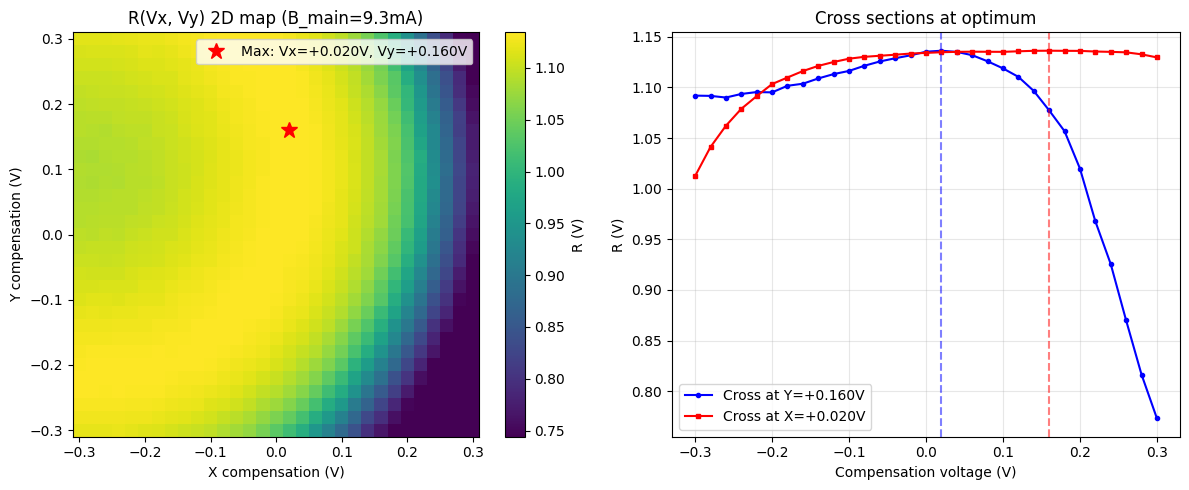

校准图已保存: d:\Code\exp_agent\data\XY_Compensation_Calibration\0518_1549_xycalib\results\xy_calibration_2d.png
颜色范围: [0.743996, 1.134378] (5%~95% 分位)
✅ 校准结果已保存: d:\Code\exp_agent\data\XY_Compensation_Calibration\0518_1549_xycalib\results\optimal_xy.yaml
  主磁场 = 9.3 mA
  Vx = +0.020 V
  Vy = +0.160 V
  R_max = 1.136161 V

💡 如需将最优值写入设备，请运行数据采集 Cell 后再运行本 Cell（保持设备连接），
   然后手动设置: dg_comp.setup_dc(+0.020, channel=1)
                 dg_comp.setup_dc(+0.160, channel=2)


In [46]:
# ===== 数据分析 & 绘图 =====
# 可以从 scan_data.npz 加载数据进行离线分析
# 即使 kernel 重启，只要运行目录存在即可恢复

# ---- 查找扫描数据目录 ----
# 如果 run_dir 不在内存中，手动指定路径：
# run_dir = project_root / "data" / EXPERIMENT_TYPE / "MMDD_HHMM_xycalib"

data_path = raw_dir / "scan_data.npz"
if data_path.exists():
    loaded = np.load(data_path)
    R_map = loaded["R_map"]
    X_values = loaded["X_values"]
    Y_values = loaded["Y_values"]
    initial_temp = float(loaded["initial_temp"])
    t_final = float(loaded["t_final"])
    X_SCAN_RANGE = float(loaded["X_SCAN_RANGE"])
    Y_SCAN_RANGE = float(loaded["Y_SCAN_RANGE"])
    XY_SCAN_POINTS = int(loaded["XY_SCAN_POINTS"])
    main_mA = float(loaded["main_magnetic_field_mA"])
    print(f"✅ 从 {data_path} 加载原始数据成功")
else:
    print(f"⚠️ 未找到 {data_path}，使用内存中的扫描数据")
    main_mA = FIXED_PARAMS["main_magnetic_field"]
    # 若 memory 中也没有则报错
    if "R_map" not in dir():
        raise FileNotFoundError(f"找不到数据文件 {data_path}，请检查路径或重新运行数据采集 Cell")

print(f"扫描数据: {XY_SCAN_POINTS}×{XY_SCAN_POINTS}, "
      f"X ±{X_SCAN_RANGE}V, Y ±{Y_SCAN_RANGE}V")
print(f"温度: {initial_temp:.2f}°C → {t_final:.2f}°C")

# ---- 全局最优 & 边界检测 ----
ij_max = np.unravel_index(np.argmax(R_map), R_map.shape)
X_opt = X_values[ij_max[0]]
Y_opt = Y_values[ij_max[1]]
R_max = R_map[ij_max]

print(f"\n🎯 最优值: Vx={X_opt:+.3f}V, Vy={Y_opt:+.3f}V, R={R_max:.6f}V")

on_x_boundary = (ij_max[0] == 0 or ij_max[0] == XY_SCAN_POINTS - 1)
on_y_boundary = (ij_max[1] == 0 or ij_max[1] == XY_SCAN_POINTS - 1)
if on_x_boundary:
    print("  ⚠️ X 方向最优值在扫描边界上！需增大 X_SCAN_RANGE 重新扫描")
if on_y_boundary:
    print("  ⚠️ Y 方向最优值在扫描边界上！需增大 Y_SCAN_RANGE 重新扫描")

# ---- 绘制 2D 校准图 ----
vmin = np.percentile(R_map, 5)
vmax = np.percentile(R_map, 95)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 左: 2D 伪彩图
im = axes[0].pcolormesh(X_values, Y_values, R_map.T,
                         cmap="viridis", shading="auto",
                         vmin=vmin, vmax=vmax)
axes[0].plot(X_opt, Y_opt, "r*", markersize=12,
             label=f"Max: Vx={X_opt:+.3f}V, Vy={Y_opt:+.3f}V")
axes[0].set_xlabel("X compensation (V)")
axes[0].set_ylabel("Y compensation (V)")
axes[0].set_title(f"R(Vx, Vy) 2D map (B_main={main_mA}mA)")
axes[0].legend()
cbar = plt.colorbar(im, ax=axes[0], label="R (V)")
cbar.ax.ticklabel_format(style="sci", scilimits=(0,0))

# 右: 穿过最优点的两条截面线
R_x_at_Yopt = R_map[:, ij_max[1]]
R_y_at_Xopt = R_map[ij_max[0], :]

axes[1].plot(X_values, R_x_at_Yopt, "b-o", markersize=3,
             label=f"Cross at Y={Y_opt:+.3f}V")
axes[1].plot(Y_values, R_y_at_Xopt, "r-s", markersize=3,
             label=f"Cross at X={X_opt:+.3f}V")
axes[1].axvline(X_opt, color="b", ls="--", alpha=0.5)
axes[1].axvline(Y_opt, color="r", ls="--", alpha=0.5)
axes[1].set_xlabel("Compensation voltage (V)")
axes[1].set_ylabel("R (V)")
axes[1].set_title("Cross sections at optimum")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plot_path = results_dir / "xy_calibration_2d.png"
fig.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"校准图已保存: {plot_path}")
print(f"颜色范围: [{vmin:.6f}, {vmax:.6f}] (5%~95% 分位)")

# ---- 保存结果 ----
result = {
    "main_magnetic_field_mA": main_mA,
    "initial_temperature_C": float(f"{initial_temp:.2f}"),
    "final_temperature_C": float(f"{t_final:.2f}"),
    "X_optimal_V": float(f"{X_opt:.3f}"),
    "Y_optimal_V": float(f"{Y_opt:.3f}"),
    "R_max_V": float(f"{R_max:.6f}"),
    "X_scan_range_V": float(X_SCAN_RANGE),
    "Y_scan_range_V": float(Y_SCAN_RANGE),
    "scan_points": XY_SCAN_POINTS,
}
result_path = results_dir / "optimal_xy.yaml"
with open(result_path, "w", encoding="utf-8") as f:
    yaml.dump(result, f, default_flow_style=False)

print(f"✅ 校准结果已保存: {result_path}")
print(f"  主磁场 = {main_mA} mA")
print(f"  Vx = {X_opt:+.3f} V")
print(f"  Vy = {Y_opt:+.3f} V")
print(f"  R_max = {R_max:.6f} V")
print()
print("💡 如需将最优值写入设备，请运行数据采集 Cell 后再运行本 Cell（保持设备连接），")
print(f"   然后手动设置: dg_comp.setup_dc({X_opt:+.3f}, channel=1)")
print(f"                 dg_comp.setup_dc({Y_opt:+.3f}, channel=2)")

In [47]:
# ===== 精细扫描 — 数据采集（可选，需设备连接） =====
# 在已找到的最优值周围，以更小范围、更密点重扫，提高精度
# 仅在需要时运行此 cell（非必须），且需要设备仍处于连接状态
#
# 如果 kernel 已重启，先运行 Cell 1~5 恢复设备连接

# 确保 X_opt, Y_opt 来自之前的分析
# （若内存中没有，尝试从 npz 加载）
if "X_opt" not in dir() or "Y_opt" not in dir():
    data_path = raw_dir / "scan_data.npz"
    if data_path.exists():
        loaded = np.load(data_path)
        R_map_orig = loaded["R_map"]
        X_values_orig = loaded["X_values"]
        Y_values_orig = loaded["Y_values"]
        ij_max_orig = np.unravel_index(np.argmax(R_map_orig), R_map_orig.shape)
        X_opt = float(X_values_orig[ij_max_orig[0]])
        Y_opt = float(Y_values_orig[ij_max_orig[1]])
        R_max = float(R_map_orig[ij_max_orig])
        print(f"✅ 从 {data_path} 加载粗扫结果: "
              f"Vx={X_opt:+.3f}V, Vy={Y_opt:+.3f}V")
    else:
        raise FileNotFoundError(
            "找不到扫描数据，请先运行数据采集 Cell 和数据分析 Cell"
        )

REFINE_FACTOR = 0.3        # 精细扫描范围为粗扫范围的 30%
REFINE_POINTS = 15         # 精细扫描点数

print("=" * 60)
print("精细扫描 — 数据采集 (Refine)")
print("=" * 60)

refine_X_range = X_SCAN_RANGE * REFINE_FACTOR
refine_Y_range = Y_SCAN_RANGE * REFINE_FACTOR
print(f"粗扫最优: Vx={X_opt:+.3f}V, Vy={Y_opt:+.3f}V")
print(f"精细范围: X ±{refine_X_range:.4f}V, Y ±{refine_Y_range:.4f}V, "
      f"{REFINE_POINTS}×{REFINE_POINTS} = {REFINE_POINTS**2} 点")
print()

X_refine = np.linspace(X_opt - refine_X_range, X_opt + refine_X_range, REFINE_POINTS)
Y_refine = np.linspace(Y_opt - refine_Y_range, Y_opt + refine_Y_range, REFINE_POINTS)
R_refine = np.zeros((REFINE_POINTS, REFINE_POINTS))

# 预温控稳定
print("等待温度稳定...")
time.sleep(3)
initial_temp_r = tec.get_temperature(channel=1)
print(f"初始温度: {initial_temp_r:.2f} °C\n")

try:
    for i, Vx in enumerate(X_refine):
        Vx = validate_safety_limit("X_magnetic_field", Vx)
        dg_comp.setup_dc(Vx, channel=1)

        dg_temp.set_output(False, channel=2)

        for j, Vy in enumerate(Y_refine):
            Vy = validate_safety_limit("Y_magnetic_field", Vy)
            dg_comp.setup_dc(Vy, channel=2)
            time.sleep(XY_SETTLE_TIME)
            s = demod.read_demod_sample(hfi, demod_idx=0)
            R_refine[i, j] = s["r"]

        dg_temp.set_output(True, channel=2)

        t_now = tec.get_temperature(channel=1)
        print(f"  X={Vx:+.3f}V: 精细扫描完成, R_max={R_refine[i].max():.6f}V, "
              f"温度 {t_now:.2f}°C (偏差 {t_now - initial_temp_r:+.3f}°C)")

        if i < len(X_refine) - 1:
            time.sleep(2)

except Exception as e:
    print(f"\n❌ 精细扫描出错: {e}")
    dg_temp.set_output(True, channel=2)
    raise

t_final_r = tec.get_temperature(channel=1)
print(f"\n✅ 精细扫描采集完成！共 {REFINE_POINTS**2} 点")
print(f"  初始温度: {initial_temp_r:.2f}°C → 最终温度: {t_final_r:.2f}°C")
print()

# ---- 保存原始数据 ----
np.savez(raw_dir / "refine_data.npz",
         R_refine=R_refine, X_refine=X_refine, Y_refine=Y_refine,
         X_opt=X_opt, Y_opt=Y_opt, R_max=R_max,
         initial_temp_r=initial_temp_r, t_final_r=t_final_r,
         REFINE_FACTOR=REFINE_FACTOR, REFINE_POINTS=REFINE_POINTS)
print(f"  精细扫描原始数据已保存: {raw_dir / 'refine_data.npz'}")

# 恢复至粗扫最优值（待分析后决策）
dg_comp.setup_dc(X_opt, channel=1)
dg_comp.setup_dc(Y_opt, channel=2)
print(f"  X/Y 补偿已恢复至粗扫最优值: Vx={X_opt:+.3f}V, Vy={Y_opt:+.3f}V")

# 恢复温控（确保打开）
dg_temp.set_output(True, channel=2)

精细扫描 — 数据采集 (Refine)
粗扫最优: Vx=+0.020V, Vy=+0.160V
精细范围: X ±0.0900V, Y ±0.0900V, 15×15 = 225 点

等待温度稳定...
初始温度: 97.39 °C

  X=-0.070V: 精细扫描完成, R_max=1.129622V, 温度 97.59°C (偏差 +0.197°C)
  X=-0.057V: 精细扫描完成, R_max=1.131130V, 温度 98.21°C (偏差 +0.813°C)
  X=-0.044V: 精细扫描完成, R_max=1.133028V, 温度 98.52°C (偏差 +1.124°C)
  X=-0.031V: 精细扫描完成, R_max=1.134509V, 温度 98.73°C (偏差 +1.331°C)
  X=-0.019V: 精细扫描完成, R_max=1.135166V, 温度 98.90°C (偏差 +1.506°C)
  X=-0.006V: 精细扫描完成, R_max=1.135610V, 温度 99.06°C (偏差 +1.661°C)
  X=+0.007V: 精细扫描完成, R_max=1.135553V, 温度 99.21°C (偏差 +1.814°C)
  X=+0.020V: 精细扫描完成, R_max=1.136097V, 温度 99.36°C (偏差 +1.966°C)
  X=+0.033V: 精细扫描完成, R_max=1.134410V, 温度 99.50°C (偏差 +2.105°C)
  X=+0.046V: 精细扫描完成, R_max=1.134746V, 温度 99.63°C (偏差 +2.241°C)
  X=+0.059V: 精细扫描完成, R_max=1.132848V, 温度 99.76°C (偏差 +2.366°C)
  X=+0.071V: 精细扫描完成, R_max=1.130291V, 温度 99.88°C (偏差 +2.483°C)
  X=+0.084V: 精细扫描完成, R_max=1.128005V, 温度 99.98°C (偏差 +2.589°C)
  X=+0.097V: 精细扫描完成, R_max=1.123475V, 温度 100.07°C (偏差 +2.672

✅ 从 d:\Code\exp_agent\data\XY_Compensation_Calibration\0518_1549_xycalib\raw\refine_data.npz 加载精细扫描数据成功
精细扫描: 15×15, factor=0.3
温度: 97.39°C → 100.15°C

🎯 粗扫最优: Vx=+0.020V, Vy=+0.160V, R=1.136161V
🎯 精扫最优: Vx=+0.020V, Vy=+0.199V, R=1.136097V


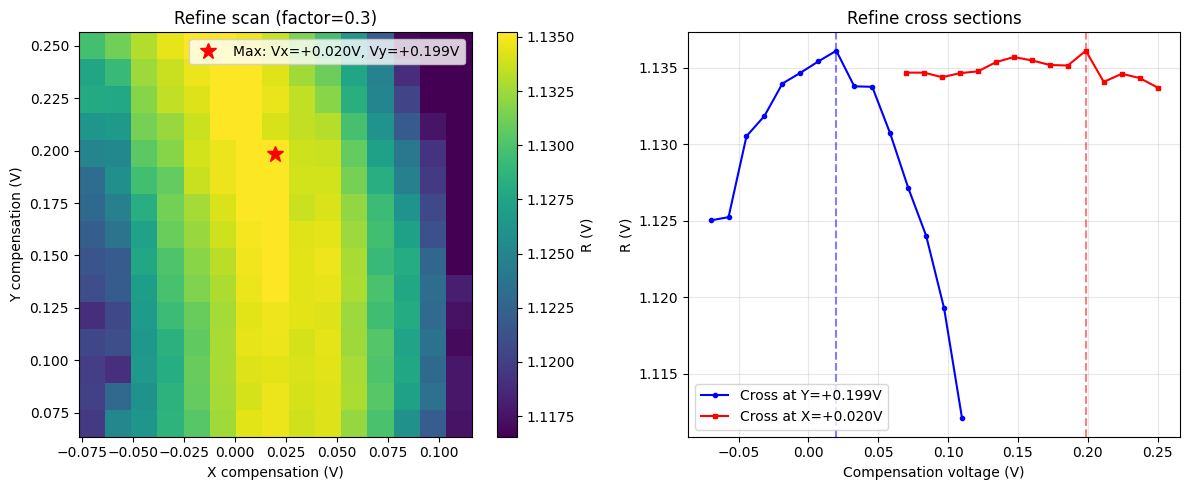

精细扫描图已保存: d:\Code\exp_agent\data\XY_Compensation_Calibration\0518_1549_xycalib\results\xy_calibration_refine.png
✅ 精扫结果已保存: d:\Code\exp_agent\data\XY_Compensation_Calibration\0518_1549_xycalib\results\refine_optimal_xy.yaml
  Vx = +0.020 V
  Vy = +0.199 V
  R_max = 1.136097 V

💡 如需将精扫最优值写入设备，请运行数据采集 Cell 后再运行本 Cell
   然后手动设置: dg_comp.setup_dc(+0.020, channel=1)
                 dg_comp.setup_dc(+0.199, channel=2)


In [48]:
# ===== 精细扫描 — 数据分析 & 绘图 =====
# 从 refine_data.npz 加载数据进行分析
# 即使 kernel 重启也可离线运行

data_path = raw_dir / "refine_data.npz"
if data_path.exists():
    loaded = np.load(data_path)
    R_refine = loaded["R_refine"]
    X_refine = loaded["X_refine"]
    Y_refine = loaded["Y_refine"]
    X_opt_origin = float(loaded["X_opt"])
    Y_opt_origin = float(loaded["Y_opt"])
    R_max_origin = float(loaded["R_max"])
    initial_temp_r = float(loaded["initial_temp_r"])
    t_final_r = float(loaded["t_final_r"])
    REFINE_FACTOR = float(loaded["REFINE_FACTOR"])
    REFINE_POINTS = int(loaded["REFINE_POINTS"])
    print(f"✅ 从 {data_path} 加载精细扫描数据成功")
else:
    print(f"⚠️ 未找到 {data_path}，使用内存中的精细扫描数据")
    if "R_refine" not in dir():
        raise FileNotFoundError(f"找不到数据文件 {data_path}，请先运行精细扫描采集 Cell")

print(f"精细扫描: {REFINE_POINTS}×{REFINE_POINTS}, factor={REFINE_FACTOR}")
print(f"温度: {initial_temp_r:.2f}°C → {t_final_r:.2f}°C")

# ---- 找最优 ----
ij_max_r = np.unravel_index(np.argmax(R_refine), R_refine.shape)
X_opt_r = X_refine[ij_max_r[0]]
Y_opt_r = Y_refine[ij_max_r[1]]
R_max_r = R_refine[ij_max_r]

# 边界检测（精细扫描坐标轴已是相对于粗扫最优，但检测中心偏差）
on_r_boundary = (ij_max_r[0] == 0 or ij_max_r[0] == REFINE_POINTS - 1 or
                 ij_max_r[1] == 0 or ij_max_r[1] == REFINE_POINTS - 1)
if on_r_boundary:
    print("  ⚠️ 精扫最优值在扫描边界上，可考虑增大 REFINE_FACTOR 重扫")

print(f"\n🎯 粗扫最优: Vx={X_opt_origin:+.3f}V, Vy={Y_opt_origin:+.3f}V, R={R_max_origin:.6f}V")
print(f"🎯 精扫最优: Vx={X_opt_r:+.3f}V, Vy={Y_opt_r:+.3f}V, R={R_max_r:.6f}V")

# 更新最优值（覆盖原变量）供后续断开 cell 使用
X_opt, Y_opt, R_max = X_opt_r, Y_opt_r, R_max_r

# ---- 绘制精细扫描对比图 ----
fig2, axes2 = plt.subplots(1, 2, figsize=(12, 5))

vmin_r = np.percentile(R_refine, 5)
vmax_r = np.percentile(R_refine, 95)

im2 = axes2[0].pcolormesh(X_refine, Y_refine, R_refine.T,
                          cmap="viridis", shading="auto",
                          vmin=vmin_r, vmax=vmax_r)
axes2[0].plot(X_opt_r, Y_opt_r, "r*", markersize=12,
              label=f"Max: Vx={X_opt_r:+.3f}V, Vy={Y_opt_r:+.3f}V")
axes2[0].set_xlabel("X compensation (V)")
axes2[0].set_ylabel("Y compensation (V)")
axes2[0].set_title(f"Refine scan (factor={REFINE_FACTOR})")
axes2[0].legend()
cbar2 = plt.colorbar(im2, ax=axes2[0], label="R (V)")
cbar2.ax.ticklabel_format(style="sci", scilimits=(0,0))

# 截面线
Rx_refine = R_refine[:, ij_max_r[1]]
Ry_refine = R_refine[ij_max_r[0], :]

axes2[1].plot(X_refine, Rx_refine, "b-o", markersize=3,
              label=f"Cross at Y={Y_opt_r:+.3f}V")
axes2[1].plot(Y_refine, Ry_refine, "r-s", markersize=3,
              label=f"Cross at X={X_opt_r:+.3f}V")
axes2[1].axvline(X_opt_r, color="b", ls="--", alpha=0.5)
axes2[1].axvline(Y_opt_r, color="r", ls="--", alpha=0.5)
axes2[1].set_xlabel("Compensation voltage (V)")
axes2[1].set_ylabel("R (V)")
axes2[1].set_title("Refine cross sections")
axes2[1].legend()
axes2[1].grid(True, alpha=0.3)

plt.tight_layout()
refine_plot_path = results_dir / "xy_calibration_refine.png"
fig2.savefig(refine_plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"精细扫描图已保存: {refine_plot_path}")

# ---- 保存精扫结果到 optimal_xy.yaml ----
result_r = {
    "main_magnetic_field_mA": float(X_opt_origin),  # 仅作占位，实际用粗扫的
    "initial_temperature_C": float(f"{initial_temp_r:.2f}"),
    "final_temperature_C": float(f"{t_final_r:.2f}"),
    "X_optimal_V_refined": float(f"{X_opt_r:.3f}"),
    "Y_optimal_V_refined": float(f"{Y_opt_r:.3f}"),
    "R_max_V_refined": float(f"{R_max_r:.6f}"),
}
result_r_path = results_dir / "refine_optimal_xy.yaml"
with open(result_r_path, "w", encoding="utf-8") as f:
    yaml.dump(result_r, f, default_flow_style=False)
print(f"✅ 精扫结果已保存: {result_r_path}")
print(f"  Vx = {X_opt_r:+.3f} V")
print(f"  Vy = {Y_opt_r:+.3f} V")
print(f"  R_max = {R_max_r:.6f} V")
print()
print("💡 如需将精扫最优值写入设备，请运行数据采集 Cell 后再运行本 Cell")
print(f"   然后手动设置: dg_comp.setup_dc({X_opt_r:+.3f}, channel=1)")
print(f"                 dg_comp.setup_dc({Y_opt_r:+.3f}, channel=2)")

## 输出说明

### 数据采集 → 数据分析 分离架构

本 notebook 采用**采集与分析分离**架构，粗扫和精扫均遵循此模式：

| 步骤 | Cell | 功能 | 需设备？ |
|------|------|------|:-------:|
| **粗扫采集** | 8 | 二维扫描 → 保存 `raw/scan_data.npz` | ✅ |
| **粗扫分析** | 9 | 加载数据 → 绘图 → 保存结果 | ❌ |
| **精扫采集** | 10 | 最优值周围精细扫描 → 保存 `raw/refine_data.npz` | ✅ |
| **精扫分析** | 11 | 加载精扫数据 → 绘图 → 保存结果 | ❌ |

这意味着采集完成后即使重启 kernel，只要运行分析 Cell 即可重新绘图。

### 边界检测

如果最优值落在扫描边界上（脚本会自动检测并告警），说明扫描范围不够大，需增大 `X_SCAN_RANGE` / `Y_SCAN_RANGE` 重新扫描。

### 精细扫描 (Refine)

扫描完成后可运行 **精扫采集 (Cell 10)**，在最优值周围以更小范围（30%）、更密点重扫，提高精度。采集完成后运行 **精扫分析 (Cell 11)** 进行绘图和保存。精扫结果会覆盖内存中的 `X_opt`, `Y_opt`，供断开 Cell 使用。

### 原始数据

扫描原始数据会自动保存到运行目录下的 `raw/` 子目录：
- `scan_data.npz` — 粗扫原始数据（R_map, X_values, Y_values 等）
- `refine_data.npz` — 精细扫描原始数据（如果运行了精扫采集 Cell）
- `refine_optimal_xy.yaml` — 精细扫描结果（如果运行了精扫分析 Cell）

## 使用说明

将数据分析 Cell 输出的最优值填入灵敏度测量 notebook 的配置参数中：

```python
FIXED_PARAMS = {
    ...
    "X_magnetic_field": {X_opt},   # ← 用校准结果替换
    "Y_magnetic_field": {Y_opt},   # ← 用校准结果替换
    ...
}
```

## 关于主磁场

主磁场由 GS200 (`main_magnetic_field`) 确定，在校准过程中**固定不变**。校准结果是针对当前主磁场大小的横磁场补偿最优值。如果改变主磁场大小，需要重新校准 X/Y 补偿。


In [49]:
# ---- 断开所有设备（保持输出状态不变） ----
if "X_opt" in dir() and "Y_opt" in dir():
    opt_msg = f"（X/Y 补偿保持 Vx={X_opt:+.3f}V, Vy={Y_opt:+.3f}V, 输出 ON）"
else:
    opt_msg = "（X/Y 补偿已恢复至 0V，输出 ON）"
print("正在断开设备...")
print(opt_msg)

for name, dev in devices.items():
    if hasattr(dev, "disconnect"):
        try:
            dev.disconnect()
            print(f"  {name} 已断开")
        except Exception as e:
            print(f"  {name} 断开失败: {e}")

print("所有设备已断开")

正在断开设备...
（X/Y 补偿保持 Vx=+0.020V, Vy=+0.199V, 输出 ON）
  gs200 已断开
  dg_comp 已断开
  dg_mod 已断开
  dg_temp 已断开
  tec 已断开
  hf2 已断开
  dg_laser 已断开
所有设备已断开
